# Model 04: XGBoost

Implementing Extreme Gradient Boosting, a highly efficient and accurate ensemble method.

In [ ]:
import os
import pickle

import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import pandas as pd
import seaborn as sns
from metrics_utils import calculate_business_metrics
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from dotenv import load_dotenv

load_dotenv()

mlflow.set_experiment("Walmart-Sales-Classification")
mlflow.set_tracking_uri("https://dagshub.com/sarah-kamall/walmart-sales-classification.mlflow")

<Experiment: artifact_location='file:///home/shehab/tmp/walmart-sales-classification/src/models/mlruns/401607475239176337', creation_time=1777790507939, experiment_id='401607475239176337', last_update_time=1777790507939, lifecycle_stage='active', name='Walmart-Sales-Classification', tags={}>

In [2]:
train_df = pd.read_csv("../../data/model_ready/train.csv")
test_df = pd.read_csv("../../data/model_ready/test.csv")

In [3]:
features_selected = [
    "Size",
    "Store",
    "Dept",
    "CPI",
    "DeptFrequency",
    "Week_cos",
    "IsPreHoliday",
    "Week_sin",
    "Fuel_Price",
    "ConsumerConfRatio",
    "AvgMarkDownAmount",
]
target = "Sales_Class"
holiday_col = "IsHoliday"

In [4]:
X_train = train_df[features_selected]
y_train = train_df[target]
X_test = test_df[features_selected]
y_test = test_df[target]
test_holidays = test_df[holiday_col]

In [5]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.1, 0.01, 0.05],
    "gamma": [0, 0.25, 1.0],
    "reg_lambda": [0, 1.0, 10.0],
    "scale_pos_weight": [1, 3, 5],
}
is_grid_search = True

In [6]:
with mlflow.start_run(run_name="XGBoost"):
    model_path = "xgboost_model.pkl"
    if os.path.exists(model_path):
        with open(model_path, "rb") as f:
            model = pickle.load(f)
        print("Model loaded from pickle")
    else:
        model = XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)
        if is_grid_search:
            grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="roc_auc", n_jobs=-1, cv=3, verbose=1)
            grid_search.fit(X_train, y_train)

            print(f"Best Parameters: {grid_search.best_params_}")
            print(f"Best Score: {grid_search.best_score_}")
            model = grid_search.best_estimator_
        else:
            model.fit(X_train, y_train)
        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        print("Model trained and saved to pickle")

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    biz_metrics = calculate_business_metrics(y_test, y_pred, test_holidays)

    mlflow.log_param("model_type", "XGBoost")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)
    mlflow.log_metric("holiday_accuracy", biz_metrics["holiday_accuracy"])
    mlflow.log_metric("weighted_classification_error", biz_metrics["weighted_classification_error"])

    mlflow.sklearn.log_model(model, artifact_path="xgboost_model.pkl")

    print(f"Accuracy: {acc:.4f}")
    print(f"Holiday Accuracy: {biz_metrics['holiday_accuracy']:.4f}")
    print(f"Weighted Error: {biz_metrics['weighted_classification_error']:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'gamma': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'reg_lambda': 0, 'scale_pos_weight': 3}
Best Score: 0.989882127289822
Model trained and saved to pickle


2026/05/03 12:51:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.9310
Holiday Accuracy: 0.9344
Weighted Error: 0.0663


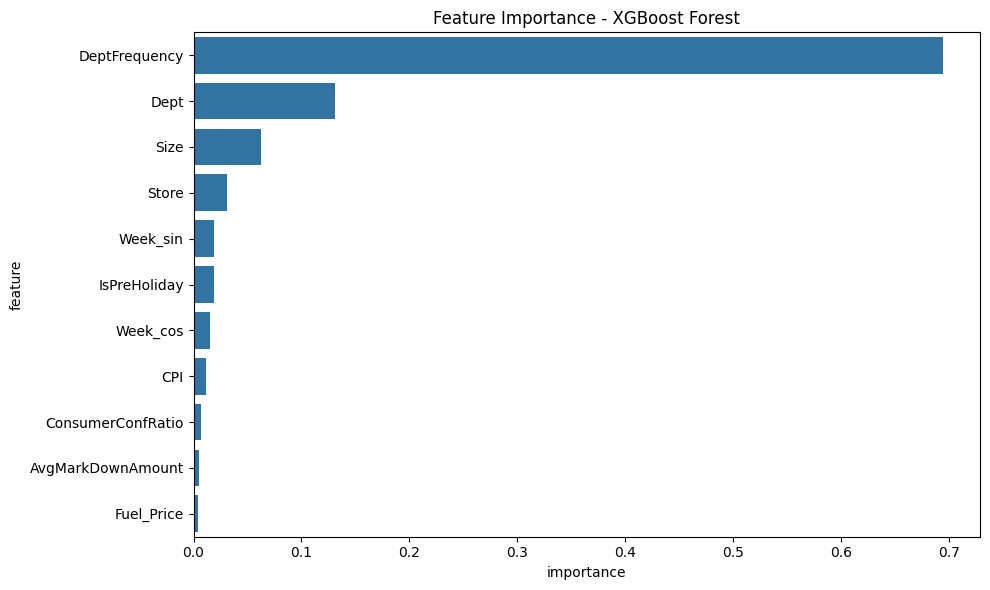

In [7]:
importances = model.feature_importances_
feature_names = features_selected
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance - XGBoost Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
mlflow.log_artifact("feature_importance.png")
plt.show()